In [1]:
import json

import h5py
import numpy as np

In [2]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [3]:
from luminareionization import fitting, fourier, utils

In [4]:
import importlib

importlib.reload(fitting)
importlib.reload(fourier)
importlib.reload(utils)

<module 'luminareionization.utils' from '/Users/vinhtran/Data/Research/Mark/Reionization Redshift/LuminaReionization/src/luminareionization/utils.py'>

In [5]:
L_box = 500
N_cell = 640
N_part = 6000**3

fourier_transform = fourier.FourierTransform(N_cell, L_box, N_part)

In [6]:
if False:
    z_reion_file = "../../Data/Sims/z_reion_V_50.hdf5"

    z_reion_data = h5py.File(z_reion_file, "r")

    z_reion_field = z_reion_data["ReionizationRedshift"][:]
    z_reion_mean = np.mean(z_reion_field)
    print(f"{z_reion_mean:.3f}")  # noqa: T201

    delta_z_reion = (z_reion_field - z_reion_mean) / (1 + z_reion_mean)

    k_mag, delta_z_reion_fourier = fourier_transform.get_fourier_transform(
        delta_z_reion
    )
    fourier_transform.save_fourier_transform(
        k_mag, delta_z_reion_fourier, "../../Data/Fourier/z_reion_V_50_fourier.h5"
    )

    # shot_noise_kernel, deconv_kernel = fourier_transform.get_conv_kernels()

    # fourier_transform.save_conv_kernels(
    #     shot_noise_kernel, deconv_kernel, "../../Data/conv_kernel.h5"
    # )

In [7]:
if False:
    rho_dm_file = "../../Data/Sims/DensityDM_156.hdf5"

    rho_dm_data = h5py.File(rho_dm_file, "r")

    rho_dm_field = rho_dm_data["DensityDM"][:]
    rho_dm_mean = np.mean(rho_dm_field)

    delta_rho_dm = (rho_dm_field - rho_dm_mean) / rho_dm_mean

    k_mag, delta_rho_dm_fourier = fourier_transform.get_fourier_transform(delta_rho_dm)
    fourier_transform.save_fourier_transform(
        k_mag,
        delta_rho_dm_fourier,
        "../../Data/Fourier/DensityDM_156_fourier.h5",
        save_k_mag=False,
    )

In [ ]:
if False:
    z_reion_fourier_file = "../../Data/Fourier/z_reion_V_50_fourier.h5"
    rho_dm_fourier_file = "../../Data/Fourier/DensityDM_156_fourier.h5"

    with h5py.File(z_reion_fourier_file, "r") as f:
        k_mag = f["WaveVector"][:]
        delta_z_reion_fourier = f["FourierTransform"][:]

    with h5py.File(rho_dm_fourier_file, "r") as f:
        delta_rho_dm_fourier = f["FourierTransform"][:]

    # with h5py.File("../../Data/conv_kernel.h5", "r") as f:
    #     shot_noise_kernel = f["ShotNoiseKernel"][:]
    #     deconv_kernel = f["DeconvKernel"][:]

    k_bins, _, P_zz, P_zz_err = fourier_transform.get_power_spectrum(
        k_mag=k_mag,
        delta_k_1=delta_z_reion_fourier,
        # shot_noise_kernel=shot_noise_kernel,
    )
    fourier_transform.save_power_spectrum(
        k_bins,
        P_zz,
        P_zz,
        P_zz_err,
        "../../Data/Fourier/z_reion_V_50_power_spectrum.json",
    )

    k_bins, _, P_mm, P_mm_err = fourier_transform.get_power_spectrum(
        k_mag=k_mag,
        delta_k_1=delta_rho_dm_fourier,
        # shot_noise_kernel=shot_noise_kernel,
    )
    fourier_transform.save_power_spectrum(
        k_bins,
        P_mm,
        P_mm,
        P_mm_err,
        "../../Data/Fourier/DensityDM_156_power_spectrum.json",
    )

    k_bins, _, P_mz, P_mz_err = fourier_transform.get_power_spectrum(
        k_mag=k_mag,
        delta_k_1=delta_rho_dm_fourier,
        delta_k_2=delta_z_reion_fourier,
        P_k_11_raw=P_mm,
        P_k_22_raw=P_zz,
    )
    fourier_transform.save_power_spectrum(
        k_bins,
        P_mz,
        P_mz,
        P_mz_err,
        "../../Data/Fourier/DensityDM_156_z_reion_V_50_cross_power_spectrum.json",
    )

In [ ]:
with open("../../Data/Fourier/z_reion_V_50_power_spectrum.json") as f:  # noqa: PTH123
    _power_spectrum_dict = json.load(f)

    for key in _power_spectrum_dict:
        _power_spectrum_dict[key] = np.array(_power_spectrum_dict[key])

    k_bins = _power_spectrum_dict["k_bins"]
    P_zz = _power_spectrum_dict["P_k"]
    P_zz_err = _power_spectrum_dict["P_k_err"]

with open("../../Data/Fourier/DensityDM_156_power_spectrum.json") as f:  # noqa: PTH123
    _power_spectrum_dict = json.load(f)

    for key in _power_spectrum_dict:
        _power_spectrum_dict[key] = np.array(_power_spectrum_dict[key])

    P_mm = _power_spectrum_dict["P_k"]
    P_mm_err = _power_spectrum_dict["P_k_err"]

with open(  # noqa: PTH123
    "../../Data/Fourier/DensityDM_156_z_reion_V_50_cross_power_spectrum.json"
) as f:
    _power_spectrum_dict = json.load(f)

    for key in _power_spectrum_dict:
        _power_spectrum_dict[key] = np.array(_power_spectrum_dict[key])

    P_mz = _power_spectrum_dict["P_k"]
    P_mz_err = _power_spectrum_dict["P_k_err"]

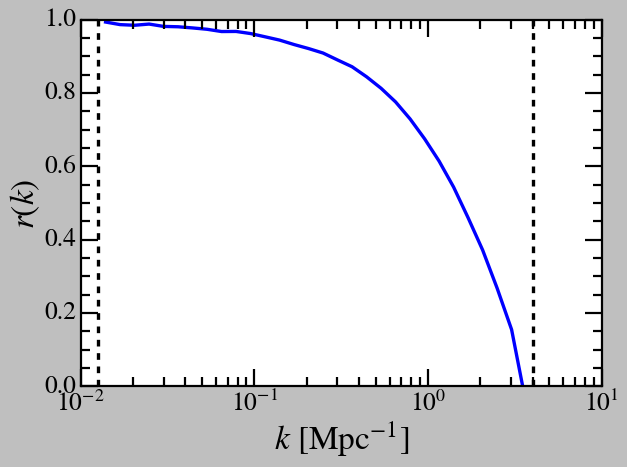

In [10]:
plt.plot(k_bins, P_mz / np.sqrt(P_mm * P_zz))

plt.axvline(fourier_transform._k_min, color="k", linestyle="--")
plt.axvline(fourier_transform._k_max, color="k", linestyle="--")

plt.xscale("log")
# plt.yscale("log")

plt.ylim(0, 1)

plt.xlabel(r"$k$ [Mpc$^{-1}$]")
plt.ylabel(r"$r(k)$")

plt.tight_layout()
plt.show()

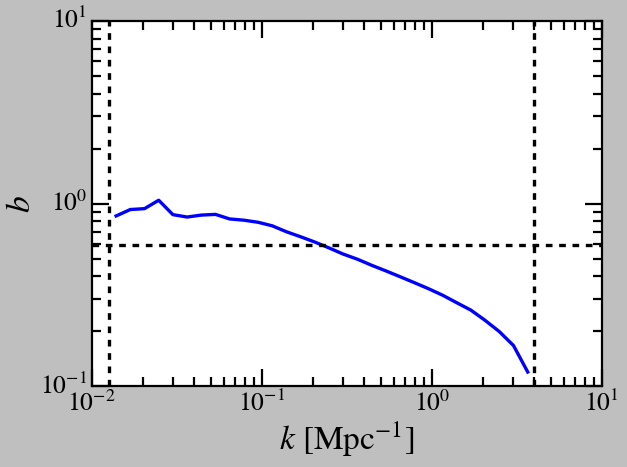

In [11]:
plt.plot(k_bins, np.sqrt(P_zz / P_mm))

plt.axvline(fourier_transform._k_min, color="k", linestyle="--")
plt.axvline(fourier_transform._k_max, color="k", linestyle="--")

plt.axhline(0.593, color="k", linestyle="--")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$k$ [Mpc$^{-1}$]")
plt.ylabel(r"$b$")

plt.tight_layout()
plt.show()

In [12]:
b_bins = np.sqrt(P_zz / P_mm)
r_bins = P_mz / np.sqrt(P_mm * P_zz)

mask = (r_bins > 0.5) & (r_bins < 1)

bias_factor_fitter = fitting.BiasFactorFitter(k_bins[mask], b_bins[mask], r_bins[mask])
fitting_results = bias_factor_fitter.fit(bounds=([1e-2, 0], [1e0, 2]))

k_interp, b_interp = bias_factor_fitter.model_interpolation(
    x=np.logspace(-2, np.log10(2), 1000), params=fitting_results["params"]
)

In [13]:
fitting_results

{'params': array([0.74901824, 1.12296299]),
 'params_err': array([ 8.59187898, 17.45748514]),
 'chisqr': np.float64(0.9885613549752928),
 'reduced_chisqr': np.float64(0.042980928477186646),
 'alpha': np.float64(0.9999999999985962),
 'cov': array([[ 73.82038442, 147.61334648],
        [147.61334648, 304.76378755]]),
 'success': True,
 'message': '`ftol` termination condition is satisfied.'}

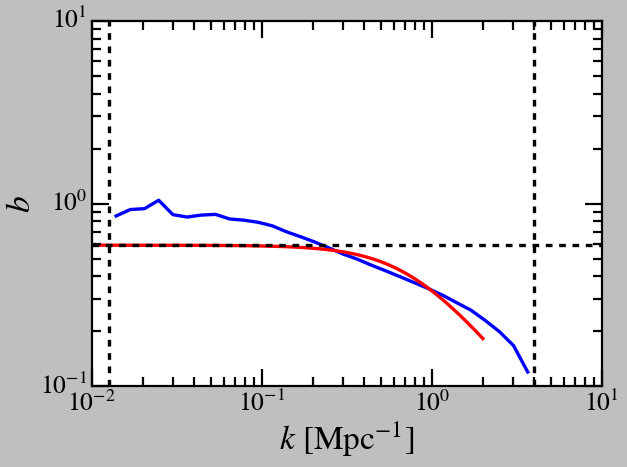

In [14]:
plt.plot(k_bins, np.sqrt(P_zz / P_mm))
plt.plot(k_interp, b_interp, color="r")

plt.axvline(fourier_transform._k_min, color="k", linestyle="--")
plt.axvline(fourier_transform._k_max, color="k", linestyle="--")

plt.axhline(0.593, color="k", linestyle="--")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$k$ [Mpc$^{-1}$]")
plt.ylabel(r"$b$")

plt.tight_layout()
plt.show()

In [16]:
if True:
    z_reion_fourier_file = "../../Data/Fourier/z_reion_V_50_fourier.h5"
    rho_dm_fourier_file = "../../Data/Fourier/DensityDM_156_fourier.h5"

    with h5py.File(z_reion_fourier_file, "r") as f:
        k_mag = f["WaveVector"][:]
        delta_z_reion_fourier = f["FourierTransform"][:]

    with h5py.File(rho_dm_fourier_file, "r") as f:
        delta_rho_dm_fourier = f["FourierTransform"][:]

    delta_z_reion_fourier_hat = delta_rho_dm_fourier * bias_factor_fitter._get_model(
        k_mag, fitting_results["params"]
    )
    delta_z_reion_hat = fourier_transform.inv_fourier_transform(
        delta_z_reion_fourier_hat
    )

    z_reion_file = "../../Data/Sims/z_reion_V_50.hdf5"

    z_reion_data = h5py.File(z_reion_file, "r")

    z_reion_field = z_reion_data["ReionizationRedshift"][:]
    z_reion_mean = np.mean(z_reion_field)

    z_reion_field_hat = delta_z_reion_hat * (1 + z_reion_mean) + z_reion_mean

    loss = np.sqrt(np.mean((1 - z_reion_field_hat / z_reion_field) ** 2))

In [17]:
loss

np.float64(0.1229381541044543)